# 📘 Notebook 03 — 03_eda_lightgbm_baseline.ipynb
## 0. Imports and Load Data

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("data/training/training_data_final.csv", parse_dates=["Date"])

print("Shape:", df.shape)
df.head()

Shape: (330939, 129)


,customer_id,product_id,customer_name,product_group,product_name,Date,ordered_qty,order_amount,unit_price,ordered_qty_observed,...,order_amount_rollstd6,order_amount_rollmean12,order_amount_rollstd12,order_amount_yoy_change,order_amount_lag12_is_zero,qty_change_1_3,qty_change_3_6,months_since_first,y_qty,y_revenue
0,7,9103373-A,TUME-AGRI,5002,0HH04503502003000505 35/20-300 A505,2015-01-01,0.0,0.0,NaN,0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,0,6.0,960.0
1,7,9103373-A,TUME-AGRI,5002,0HH04503502003000505 35/20-300 A505,2015-02-01,6.0,960.0,160.0,1,...,NaN,0.0,NaN,NaN,0,NaN,NaN,1,0.0,0.0
2,7,9103373-A,TUME-AGRI,5002,0HH04503502003000505 35/20-300 A505,2015-03-01,0.0,0.0,160.0,0,...,678.822510,480.0,678.822510,NaN,0,NaN,NaN,2,0.0,0.0
3,7,9103373-A,TUME-AGRI,5002,0HH04503502003000505 35/20-300 A505,2015-04-01,0.0,0.0,160.0,0,...,554.256258,320.0,554.256258,NaN,0,NaN,NaN,3,0.0,0.0
4,7,9103373-A,TUME-AGRI,5002,0HH04503502003000505 35/20-300 A505,2015-05-01,0.0,0.0,160.0,0,...,480.000000,240.0,480.000000,NaN,0,0.0,NaN,4,0.0,0.0


## 1. Basic EDA / Data quality checks
### 1.1 Check missing

In [3]:
df.isna().mean().sort_values(ascending=False).head(20)
df = df.fillna(0)

### 1.2 Check time coverage

In [4]:
series_lengths = (
    df.groupby(['customer_id','product_id'])['Date']
      .nunique()
      .sort_values()
)

print(series_lengths.describe())
series_lengths.head()

count    2785.000000
mean      118.829084
std         3.560169
min         2.000000
25%       119.000000
50%       119.000000
75%       119.000000
max       119.000000
Name: Date, dtype: float64


customer_id  product_id
5603         5005061        2
             5011019       48
7417         304492        51
             303938        56
             303938        63
Name: Date, dtype: int64

### 1.3 Plot a sample series (visual intuition)

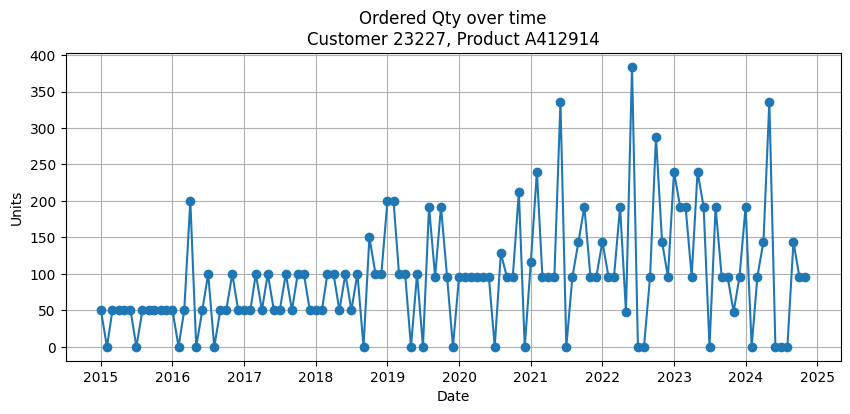

In [5]:
sample_pair = df.groupby(['customer_id','product_id'])['ordered_qty'].sum().sort_values(ascending=False).index[0]
sample_customer, sample_product = sample_pair

plot_df = df[(df['customer_id']==sample_customer) & (df['product_id']==sample_product)].sort_values('Date')

plt.figure(figsize=(10,4))
plt.plot(plot_df['Date'], plot_df['ordered_qty'], marker='o')
plt.title(f"Ordered Qty over time\nCustomer {sample_customer}, Product {sample_product}")
plt.xlabel("Date")
plt.ylabel("Units")
plt.grid(True)
plt.show()

## 2. Train / validation split design
### 2.1 Add helper time index

In [6]:
# numeric time index for model, useful later also for TFT
df = df.sort_values(['customer_id','product_id','Date']).reset_index(drop=True)
df['time_idx'] = df.groupby(['customer_id','product_id']).cumcount()

### 2.2 Define features and target

In [7]:
target_col = 'ordered_qty'

# columns we know are identifiers or target
id_cols = ['customer_id','product_id','customer_name','product_group','product_name','Date','time_idx']
avoid_cols = id_cols + [target_col]

feature_cols = [c for c in df.columns 
                if c not in avoid_cols 
                and not c.endswith('_is_real')]  # we CAN include _is_real later for TFT

print("Number of features:", len(feature_cols))
feature_cols[:20]

Number of features: 114


['order_amount',
 'unit_price',
 'ordered_qty_observed',
 'order_amount_observed',
 'unit_price_observed',
 'unit_price_missing',
 'Food_Price_Index',
 'Electricity_Price',
 'ECB_Inflation',
 'ECB_Interest_Rate',
 'FEDFUNDS_Value',
 'Purchase_Index',
 'Total_New_Orders_Value',
 'Steel_Price',
 'Food_Price_Index_missing',
 'Food_Price_Index_lag1',
 'Food_Price_Index_lag2',
 'Food_Price_Index_lag3',
 'Food_Price_Index_rollmean3',
 'Food_Price_Index_rollstd3']

### 2.3 Train/Val split logic per series

In [8]:
def train_val_split_per_series(g):
    # sort by Date
    g = g.sort_values('Date')
    if len(g) <= 12:
        # too short: all goes to train, none to val
        g['is_val'] = False
    else:
        g['is_val'] = False
        g.iloc[-12:, g.columns.get_loc('is_val')] = True
    return g

df = df.groupby(['customer_id','product_id'], group_keys=False).apply(train_val_split_per_series)

train_df = df[df['is_val'] == False].copy()
val_df   = df[df['is_val'] == True].copy()

print("Train rows:", train_df.shape[0])
print("Val rows:", val_df.shape[0])

Train rows: 297531
Val rows: 33408


## 3. Train LightGBM baseline

In [9]:
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

train_dataset = lgb.Dataset(X_train, label=y_train)
val_dataset   = lgb.Dataset(X_val, label=y_val)

model = LGBMRegressor(
    objective="regression",
    learning_rate=0.05,
    num_leaves=64,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    min_data_in_leaf=20,
    lambda_l1=0.0,
    lambda_l2=0.0,
    n_estimators=2000,
    random_state=42,
)

# --- NEW STYLE FOR v4+ ---
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="mae",
    callbacks=[
        early_stopping(stopping_rounds=100),
        log_evaluation(period=100)
    ]
)

val_pred = model.predict(X_val)

mae = mean_absolute_error(y_val, val_pred)

# sMAPE (symmetric MAPE) is good for demand forecasting:
def smape(y_true, y_pred):
    num = np.abs(y_pred - y_true)
    den = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    # avoid /0
    ratio = np.where(den == 0, 0, num / den)
    return np.mean(ratio) * 100.0

smape_val = smape(y_val.values, val_pred)

print(f"Validation MAE:   {mae:.3f}")
print(f"Validation sMAPE: {smape_val:.2f}%")

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=0.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0
[LightGBM] [Warning] lambda_l2 is set=0.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=0.0, reg_alpha=0.0 will be ignored. Cu

## 4. Inspect feature importance (business interpretability)

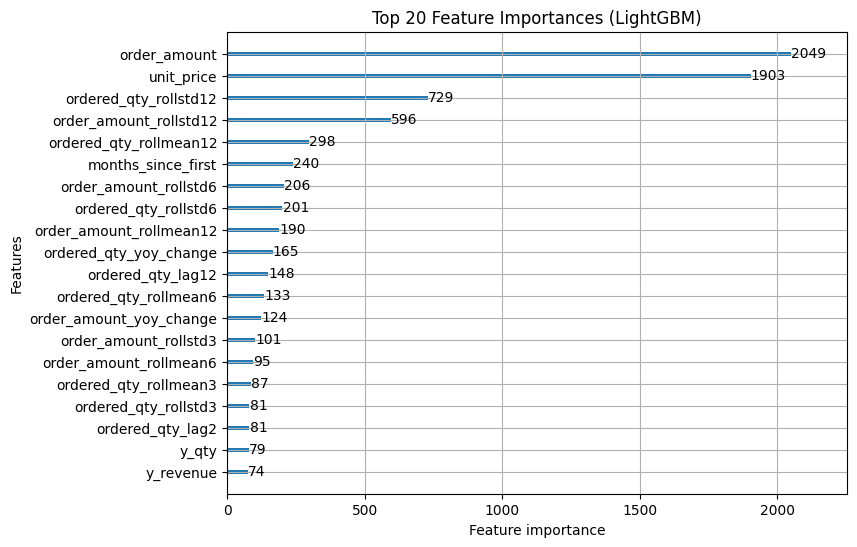

In [10]:
lgb.plot_importance(model, max_num_features=20, figsize=(8,6))
plt.title("Top 20 Feature Importances (LightGBM)")
plt.show()

## 5. Generate forward forecasts (next 12 months)
### 5.1 Attach predictions back to val_df

In [11]:
val_results = val_df.copy()
val_results['forecast_qty'] = val_pred
val_results['abs_error'] = np.abs(val_results['forecast_qty'] - val_results['ordered_qty'])

val_results[['customer_id','product_id','Date','ordered_qty','forecast_qty','abs_error']].head()

,customer_id,product_id,Date,ordered_qty,forecast_qty,abs_error
107,7,9103373-A,2023-12-01,0.0,0.000289,0.000289
108,7,9103373-A,2024-01-01,0.0,0.000289,0.000289
109,7,9103373-A,2024-02-01,0.0,0.000289,0.000289
110,7,9103373-A,2024-03-01,0.0,0.000289,0.000289
111,7,9103373-A,2024-04-01,0.0,0.000289,0.000289


### 5.2 Derive simple trend classification

In [12]:
def label_trend(g, history_window=6, future_window=6, threshold=0.10):
    g = g.sort_values('Date')
    # past avg: last N actuals before forecast window
    past = g[~g['is_val']].tail(history_window)['ordered_qty'].mean()
    future = g[g['is_val']].head(future_window)['forecast_qty'].mean()
    if pd.isna(past) or past == 0:
        return "unstable"
    change = (future - past) / past
    if change > threshold:
        return "increasing"
    elif change < -threshold:
        return "decreasing"
    else:
        return "stable"

trend_labels = (
    val_results.groupby(['customer_id','product_id'])
               .apply(label_trend)
               .reset_index()
               .rename(columns={0:'trend_flag'})
)

trend_labels.head()


,customer_id,product_id,trend_flag
0,7,9103373-A,unstable
1,7,9117073-A,unstable
2,7,9117173-A,unstable
3,7,9404373,unstable
4,7,9440273,unstable


## 6. Save baseline forecasts for downstream use

In [13]:
# Save validation predictions and trend tags
out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

val_results_out = val_results.merge(trend_labels, on=['customer_id','product_id'], how='left')

val_results_out.to_csv(f"{out_dir}/baseline_lightgbm_forecast_results.csv", index=False)
print("✅ Saved baseline predictions to outputs/baseline_lightgbm_forecast_results.csv")

✅ Saved baseline predictions to outputs/baseline_lightgbm_forecast_results.csv


In [14]:
# --- Ensure ID data types consistent before saving ---
# Loop through whichever DataFrames exist in this notebook
for name in ["train_df", "val_df", "test_df", "forecast_df"]:
    if name in locals():
        df_ = locals()[name]
        if "customer_id" in df_.columns:
            df_["customer_id"] = df_["customer_id"].astype(str).str.strip()
        if "product_id" in df_.columns:
            df_["product_id"] = df_["product_id"].astype(str).str.strip()
        print(f"✅ Cleaned ID columns in {name}")

# When exporting forecast results
if "forecast_df" in locals():
    forecast_df["customer_id"] = forecast_df["customer_id"].astype(str).str.strip()
    forecast_df["product_id"] = forecast_df["product_id"].astype(str).str.strip()
    forecast_df.to_csv("outputs/baseline_lightgbm_forecast_results.csv", index=False)
    print("✅ Saved baseline forecast with aligned ID data types.")


✅ Cleaned ID columns in train_df
✅ Cleaned ID columns in val_df
